In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from gensim import models, corpora 
from itertools import combinations
import pyLDAvis
import pyLDAvis.gensim_models 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import umap
import hdbscan
import ast
import plotly.express as px 
import pickle


import spacy 
import string
import random
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
# from pyod.models.xgbod import XGBOD
# from sentence_transformers import SentenceTransformer
# conda install pyod 
# conda install xgboost

/ocean/projects/cis240109p/mmarius/env/PNC2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# to remove stop words 
nlp = spacy.load("en_core_web_sm")
stop_words = nlp.Defaults.stop_words
stop_words= list(stop_words) + ['card','I']
def remove_stopwords(text):
    
    # Convert to lowercase converts to tokens so easy to get lemmatize 
    doc = nlp(text.lower())
    cleaned_words = [
    token.lemma_  # Lemmatization
    for token in doc
    if token.lemma_ not in string.punctuation and token.lemma_ not in stop_words
    
]

    return " ".join(cleaned_words)


def remove_stopwords_woLemma(text):
    
    # Convert to lowercase converts to tokens so easy to get lemmatize 
    doc = nlp(text.lower())
    cleaned_words = [
    token.text  # Lemmatization
    for token in doc
    if token.text not in string.punctuation and token.text not in stop_words
    
]

    return " ".join(cleaned_words)

In [3]:


# scorer used to find best cluster
def hdbscan_scorer(estimator, X):
    estimator.fit(X)
    # Return the relative_validity_ attribute (DBCV score)
    if hasattr(estimator, 'relative_validity_'):
        return estimator.relative_validity_
    else:
        return -np.inf  # Return negative infinity if no score is available


In [12]:
train=pd.read_csv('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/task-specific-datasets/banking_data/train.csv')
test=pd.read_csv('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/task-specific-datasets/banking_data/test.csv')
data=pd.concat([train,test]).reset_index()
data=data.drop(columns=['index'])

In [13]:
vec_data= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/embedding.npy')

# KMEANS with BERT

Silhou score

In [ ]:
# finding optimal number of clusters

inertia = []  # Stores the sum of squared distances (WCSS)
silhouette_scores=[] # Stores sil scores

K_range = range(2, 51)  
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(vec_data)
    inertia.append(kmeans.inertia_)  # Sum of squared distances to centroids
    labels = kmeans.fit_predict(vec_data)
    score = silhouette_score(vec_data, labels)
    silhouette_scores.append(score)

# Plot Elbow Curve
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.show()

# Plot Silhouette Scores
plt.plot(range(2, 51), silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.show()


# Making Kmeans model based on scores

In [6]:
# K means model based on graph above 

kmeans = KMeans(n_clusters=91, random_state=42)
labels_km = kmeans.fit_predict(vec_data)
centroids = kmeans.cluster_centers_


visualizing Kmeans with TSNE 

/tmp/ipykernel_910154/995829464.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


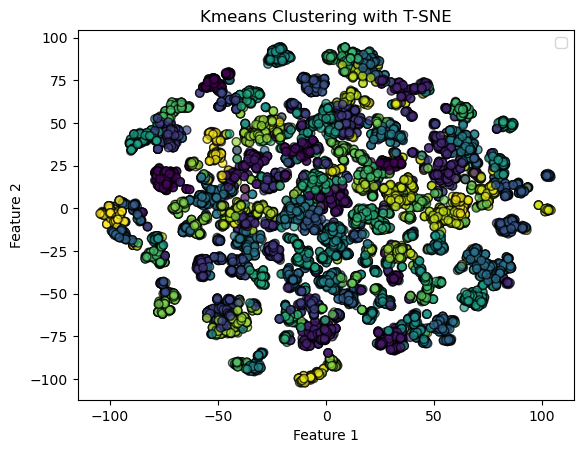

In [7]:
 
# if this works , else run line below
# tsne = TSNE(n_components=2)
# data_ts = tsne.fit_transform(vec_data)

data_ts= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/TSNE.npy')


# plot data 
plt.scatter(data_ts[:, 0], data_ts[:, 1], c=labels_km, cmap='viridis', alpha=0.7, edgecolors='k')

# Labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Kmeans Clustering with T-SNE')
plt.legend()
plt.show()

3D TSNE Plot with top 5 word frequincies

In [7]:

data_ts_3= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/TSNE_3.npy')
T_SNE = pd.DataFrame(data_ts_3, columns= ['PC1','PC2','PC3'])
T_SNE['labels_km']=labels_km
T_SNE['text']=data['text']




# looping and sorting based on labels to get word frequincies ( can make this a function)
labels_frequency=[]
num_in_class=[]
for label in np.unique(T_SNE['labels_km']):
    frequency=[]
    # removing stopword and not lemmatizng so to 5 words are useful
    texts = [document.lower().split() for document in T_SNE['text'][T_SNE['labels_km']==label].apply(remove_stopwords_woLemma)]
    num_in_class.append(len(texts)) # making list of total datapoints for each class
    dictionary = corpora.Dictionary(texts)
    # sorting
    sorted_words = sorted(dictionary.dfs.items(), key=lambda x: x[1], reverse=True)

    for id, freq in sorted_words[:5]:  # Top 5 most frequent
        frequency.append(f'{dictionary[id]}:{freq}')
        # adding to final list that'll have all top 5 words frequencies for each labels 
    labels_frequency.append(frequency)

T_SNE['freq']=T_SNE['labels_km'].apply(lambda x: labels_frequency[x] )
T_SNE['count']=T_SNE['labels_km'].apply(lambda x: num_in_class[x] )

In [9]:

fig = px.scatter_3d(T_SNE, x='PC1', y='PC2', z='PC3',color='labels_km',hover_data=['text','freq','count'], opacity=0.7)

# fig = px.scatter_3d(TNSE_3, x='PC1', y='PC2', z='PC3',color='labels_km', opacity=0.7)
fig.update_traces(marker=dict(size=3))
fig.update_layout(title="3D PCA Plot of Kmeans-TSNE")
fig.write_html("Kmeans-TSNE.html")

# Reducing clusters (73)

In [13]:
# grouping clusters that are similar based on visual  
T_SNE['labels_km']=T_SNE['labels_km'].astype(int)
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x :  3 if x == 39 or x == 62 else x ) # 3/39/62 
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 90 if x == 29 or x == 27 else x )# virtual card (not working)
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 64 if x == 47 else x )# disposiable cards
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 74 if x == 33 else x )# new card 
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 73 if x == 35 else x )#73/35 delevery
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 17 if x == 51 else x ) #pin questions (65 anomaly)
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 61 if x == 32 or x == 81 else x ) # refund
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 34 if x == 12 else x ) # 34/12 wrong exchange rate 
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 36 if x == 15 else x )#36/15 # atm 
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 42 if x == 66 else x )# changing personal info
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x :  5 if x == 57 else x )#5/57 extra charges 
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 72 if x == 22 else x )#72 22 child to card
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 87 if x == 75 else x )# 87 75 top up verification
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 19 if x == 77 else x )# 19 77 id verificacation
T_SNE['labels_km']=T_SNE['labels_km'].apply (lambda x : 20 if x == 55 else x )# 20/55 lost phone/ app issue

# 69 28 8(mainly isssues with top up topup

In [14]:
len(np.unique(T_SNE['labels_km']))

73

In [9]:
# same as earlier but running with updated labels 

labels_frequency_dict = {}  
num_in_class_dict = {}   
for label in np.unique(T_SNE['labels_km']):
    frequency=[]
    # removing stopword and not lemmatizng so to 5 words are useful
    texts = [document.lower().split() for document in T_SNE['text'][T_SNE['labels_km']==label].apply(remove_stopwords_woLemma)]
    num_in_class_dict[label] = len(texts)

    dictionary = corpora.Dictionary(texts)
    # sorting
    sorted_words = sorted(dictionary.dfs.items(), key=lambda x: x[1], reverse=True)

    labels_frequency_dict[label] = ", ".join([f"{dictionary[id]}:{freq}" for id, freq in sorted_words[:5]])

T_SNE['freq'] = T_SNE['labels_km'].map(labels_frequency_dict)
T_SNE['count'] = T_SNE['labels_km'].map(num_in_class_dict)



In [11]:
fig = px.scatter_3d(T_SNE, x='PC1', y='PC2', z='PC3',color='labels_km',hover_data=['text','freq','count'], opacity=0.7)
fig.update_traces(marker=dict(size=3))
fig.update_layout(title="3D PCA Plot of Kmeans-TSNE reduced")
fig.write_html("Kmeans-TSNE_reduced.html")

# 10 clusters 

In [6]:
# K means model based on graph above 

kmeans = KMeans(n_clusters=10, random_state=42)
labels_km = kmeans.fit_predict(vec_data)
centroids = kmeans.cluster_centers_


/tmp/ipykernel_2476771/995829464.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


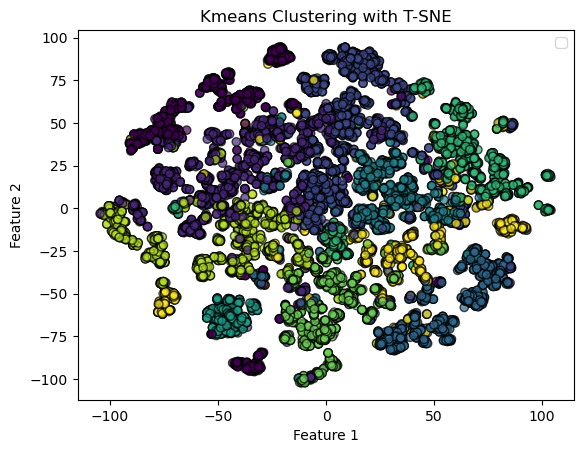

In [8]:
 
# if this works , else run line below
# tsne = TSNE(n_components=2)
# data_ts = tsne.fit_transform(vec_data)

data_ts= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/TSNE.npy')


# plot data 
plt.scatter(data_ts[:, 0], data_ts[:, 1], c=labels_km, cmap='viridis', alpha=0.7, edgecolors='k')

# Labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Kmeans Clustering with T-SNE')
plt.legend()
plt.show()

In [9]:

data_ts_3= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/TSNE_3.npy')
T_SNE = pd.DataFrame(data_ts_3, columns= ['t-SNE1','t-SNE2','t-SNE3'])
T_SNE['labels_km']=labels_km
T_SNE['text']=data['text']




# looping and sorting based on labels to get word frequincies ( can make this a function)
labels_frequency=[]
num_in_class=[]
for label in np.unique(T_SNE['labels_km']):
    frequency=[]
    # removing stopword and not lemmatizng so to 5 words are useful
    texts = [document.lower().split() for document in T_SNE['text'][T_SNE['labels_km']==label].apply(remove_stopwords_woLemma)]
    num_in_class.append(len(texts)) # making list of total datapoints for each class
    dictionary = corpora.Dictionary(texts)
    # sorting
    sorted_words = sorted(dictionary.dfs.items(), key=lambda x: x[1], reverse=True)

    for id, freq in sorted_words[:5]:  # Top 5 most frequent
        frequency.append(f'{dictionary[id]}:{freq}')
        # adding to final list that'll have all top 5 words frequencies for each labels 
    labels_frequency.append(frequency)

T_SNE['freq']=T_SNE['labels_km'].apply(lambda x: labels_frequency[x] )
T_SNE['count']=T_SNE['labels_km'].apply(lambda x: num_in_class[x] )

In [10]:
fig = px.scatter_3d(T_SNE, x='t-SNE1', y='t-SNE2', z='t-SNE3',color='labels_km',hover_data=['text','freq','count'], opacity=0.7)
fig.update_traces(marker=dict(size=3))
fig.update_layout(title="3D Tsne Plot of Kmeans 10 clusters")
fig.write_html("Kmeans-TSNE_10cluster.html")

label 0
- change account details/name, pin, passowrd, adress, and stolen phone  issues (delete acount also )

label 1
- virtual card rejections, activation, tracking, non-functioning, lost , experation

label 2
- multiple charges/fees, refund, cancel transaction, unrecognized transactions. 

label 3
- exchange rate, currency excahnge fees, exchanging through app, incorrect exchange rate 

label 4 
- app cash withdraw without notice, cash withdraw atm/app, withdraw fees, some deposite

label 5
- identity check/ verification

label 6 
- failed transfer , timeline for transfer, transfer rejection, 

label 7 
-  top up questions, top up being denied, 

label 8
- virtual disposable cards , owning/buyin a virtual disposabel card , choosing visa pr master card,

label 9
- source of funding/ where money is, age req for opening account,transfer funds from acount to acount 


# 40 clusters

In [11]:
# K means model based on graph above 

kmeans = KMeans(n_clusters=40, random_state=42)
labels_km = kmeans.fit_predict(vec_data)
centroids = kmeans.cluster_centers_


/tmp/ipykernel_2476771/995829464.py:15: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



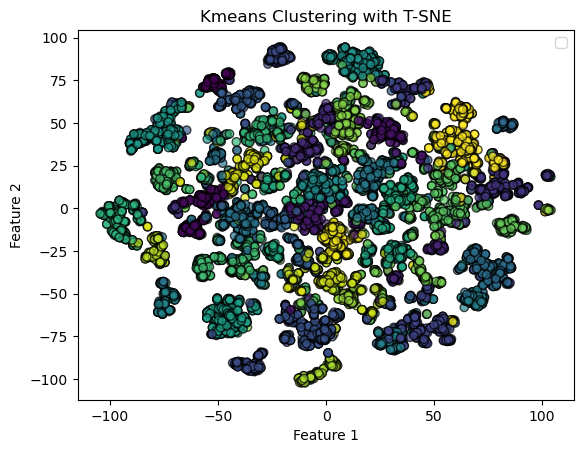

In [12]:
 
# if this works , else run line below
# tsne = TSNE(n_components=2)
# data_ts = tsne.fit_transform(vec_data)

data_ts= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/TSNE.npy')


# plot data 
plt.scatter(data_ts[:, 0], data_ts[:, 1], c=labels_km, cmap='viridis', alpha=0.7, edgecolors='k')

# Labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Kmeans Clustering with T-SNE')
plt.legend()
plt.show()

In [13]:

data_ts_3= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/TSNE_3.npy')
T_SNE = pd.DataFrame(data_ts_3, columns= ['t-SNE1','t-SNE2','t-SNE3'])
T_SNE['labels_km']=labels_km
T_SNE['text']=data['text']




# looping and sorting based on labels to get word frequincies ( can make this a function)
labels_frequency=[]
num_in_class=[]
for label in np.unique(T_SNE['labels_km']):
    frequency=[]
    # removing stopword and not lemmatizng so to 5 words are useful
    texts = [document.lower().split() for document in T_SNE['text'][T_SNE['labels_km']==label].apply(remove_stopwords_woLemma)]
    num_in_class.append(len(texts)) # making list of total datapoints for each class
    dictionary = corpora.Dictionary(texts)
    # sorting
    sorted_words = sorted(dictionary.dfs.items(), key=lambda x: x[1], reverse=True)

    for id, freq in sorted_words[:5]:  # Top 5 most frequent
        frequency.append(f'{dictionary[id]}:{freq}')
        # adding to final list that'll have all top 5 words frequencies for each labels 
    labels_frequency.append(frequency)

T_SNE['freq']=T_SNE['labels_km'].apply(lambda x: labels_frequency[x] )
T_SNE['count']=T_SNE['labels_km'].apply(lambda x: num_in_class[x] )

In [14]:
fig = px.scatter_3d(T_SNE, x='t-SNE1', y='t-SNE2', z='t-SNE3',color='labels_km',hover_data=['text','freq','count'], opacity=0.7)
fig.update_traces(marker=dict(size=3))
fig.update_layout(title="3D Tsne Plot of Kmeans 40 clusters")
fig.write_html("Kmeans-TSNE_40cluster.html")

# HDB SCAN

min_cluster_size
- sets the minimum number of points required to form a cluster
- Lower values: Create more clusters, 
- Higher values: Produce fewer, larger clusters by merging smaller ones

min_samples

- defines the number of points required to form core points (dense regions)
- Lower values: fewer noise points
- Higher values: more points declared as noise

cluster_selection_method

- 'eom' (default): Uses Excess of Mass algorithm to find the most persistent clusters
- 'leaf': Selects leaf nodes from the tree, producing smaller, more homogeneous clusters


# Using coherence Score to judge models 




# Set 1

param_dist = {
    'min_cluster_size': [10,20,30],
    'min_samples': [150,200,300],
    'cluster_selection_method':['leaf','eom'],
    'cluster_selection_epsilon':[0,.5,1,1.5,2]
 
}

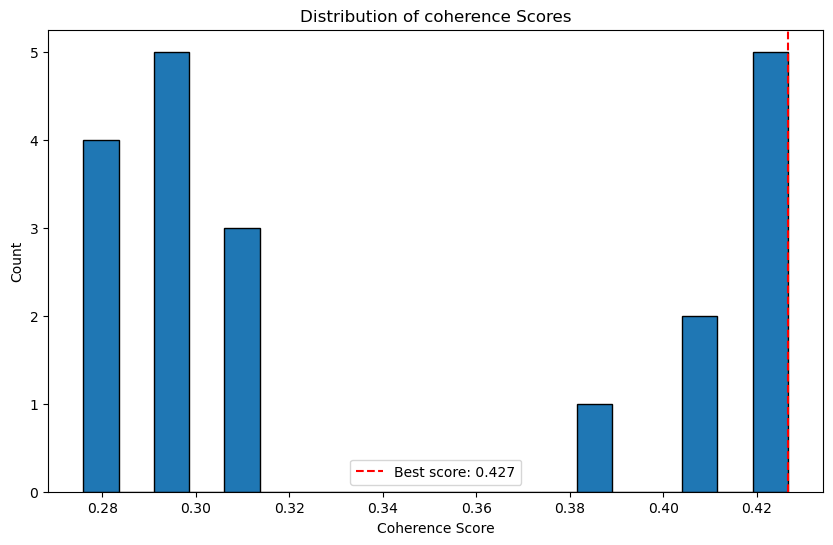

In [2]:

random_search_7 = pd.read_csv('hdbscan_optimization_results_1.csv')


results = pd.json_normalize(random_search_7['params'].apply(ast.literal_eval))
results['labels']= random_search_7['labels']
results['scores']= random_search_7['score']




# result=pd.DataFrame({'scores':random_search_7['score'],'min_samples':min_samp , 'min_cluster_size':min_cluster, 'cluster_selection_method':cluster_method, 'cluster_selection_epsilon':cluster_epsilon, 'labels':random_search_7['labels']})


# Sort by score to see best parameters
results = results.sort_values('scores', ascending=False)

# Plot the distribution of scores
plt.figure(figsize=(10, 6))
plt.hist(results['scores'], bins=20,edgecolor='black')
plt.axvline(results['scores'][0], color='r', linestyle='--', label=f'Best score: {results['scores'][0]:.3f}') # making base line 
plt.title('Distribution of coherence Scores')
plt.xlabel('Coherence Score')
plt.ylabel('Count')
plt.legend()
plt.show()


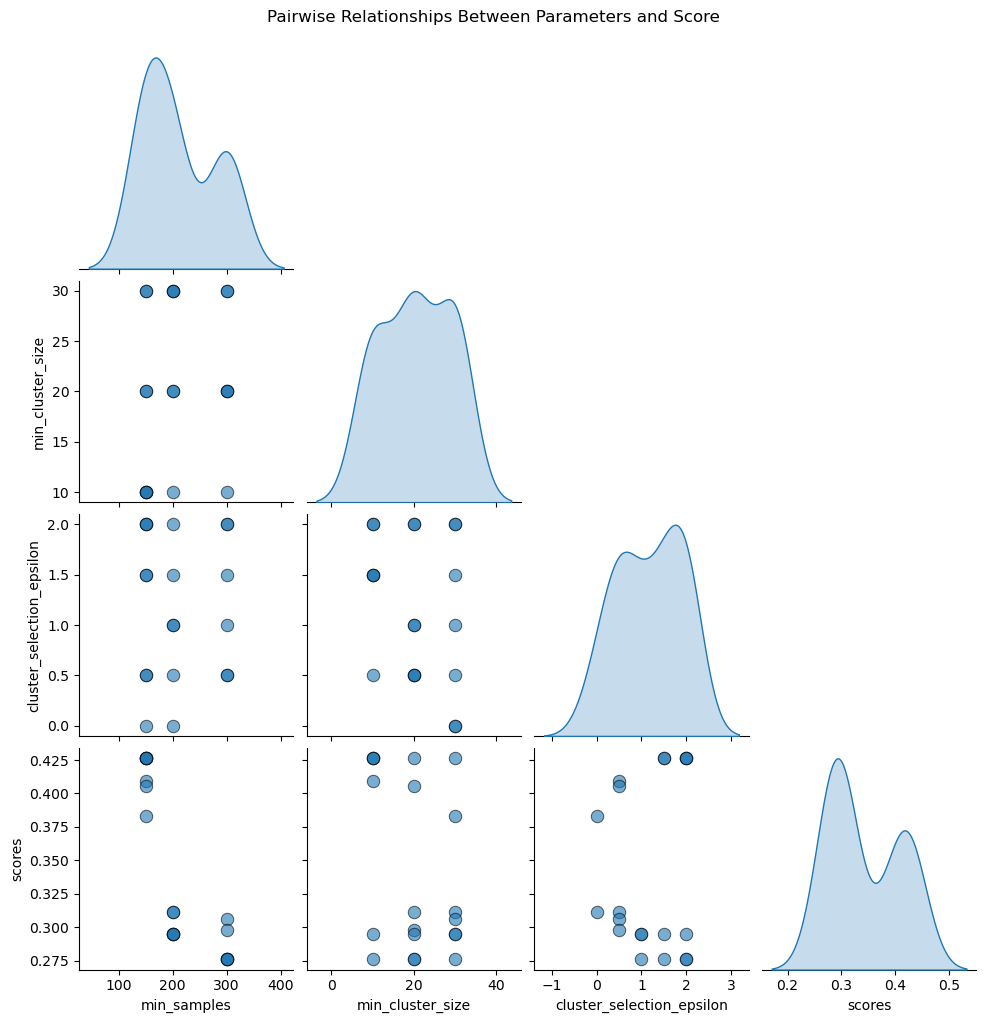

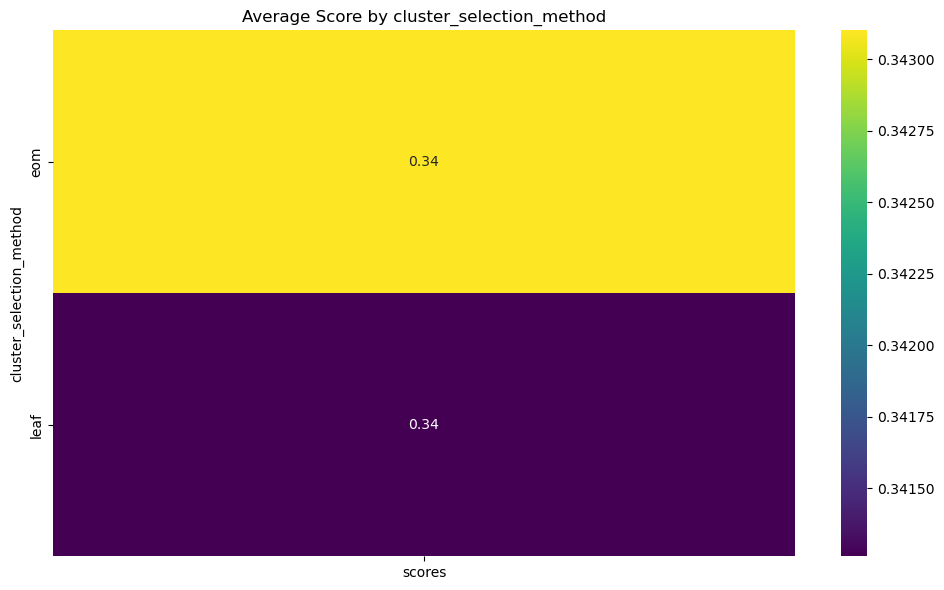

In [3]:
# Create a pairplot for numerical parameters
numerical_params = results.select_dtypes(include=['number']).columns.tolist()
# if 'scores' not in numerical_params:
    # numerical_params.append('scores')
    # Move 'scores' to the front if it's in the list
if 'scores' in numerical_params:
    numerical_params.append(numerical_params.pop(numerical_params.index('scores')))

sns.pairplot(results[numerical_params], corner=True, kind='scatter', 
             diag_kind='kde', plot_kws={'alpha': 0.6, 'edgecolor': 'k', 's': 80})
plt.suptitle('Pairwise Relationships Between Parameters and Score', y=1.02)
plt.show()

# For categorical parameters, create heatmaps
categorical_params = results.select_dtypes(include=['object']).columns.tolist()

if categorical_params:
    for param in categorical_params:
        if param == 'labels':
            continue
        plt.figure(figsize=(10, 6))
        pivot = results.pivot_table(index=param, values='scores', aggfunc=['mean', 'std', 'count'])
        sns.heatmap(pivot['mean'], annot=True, cmap='viridis')
        plt.title(f'Average Score by {param}')
        plt.tight_layout()
        plt.show()


Curious just looking at the 10 clusters

In [24]:
# Get the worst parameters
params = results.iloc[5][:-2].to_dict()

new_clusterer = hdbscan.HDBSCAN(**params)
new_clusterer.fit(vec_data)

labels = new_clusterer.labels_
print(len(np.unique(labels)))

11


/tmp/ipykernel_2041034/3132968407.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


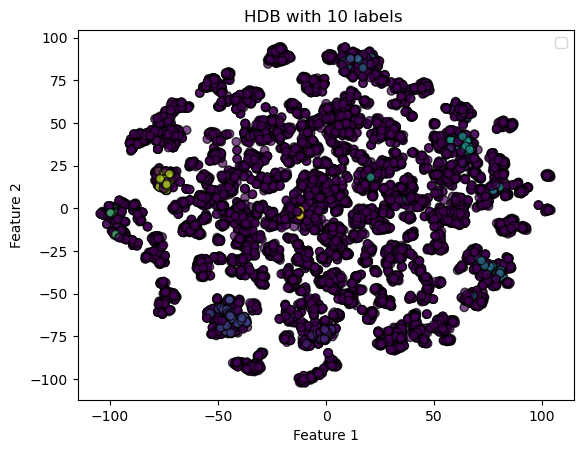

In [25]:
# plot data 
data_ts= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/TSNE.npy')
plt.scatter(data_ts[:, 0], data_ts[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolors='k')

# Labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('HDB with 10 labels ')
plt.legend()
plt.show()

 # Set2 

param_dist = {
    'min_cluster_size': [10,20,30,40],
    'min_samples': [50,100,150],
    'cluster_selection_method':['leaf','eom'],
    'cluster_selection_epsilon':[1.5,2,3,4]
 
}

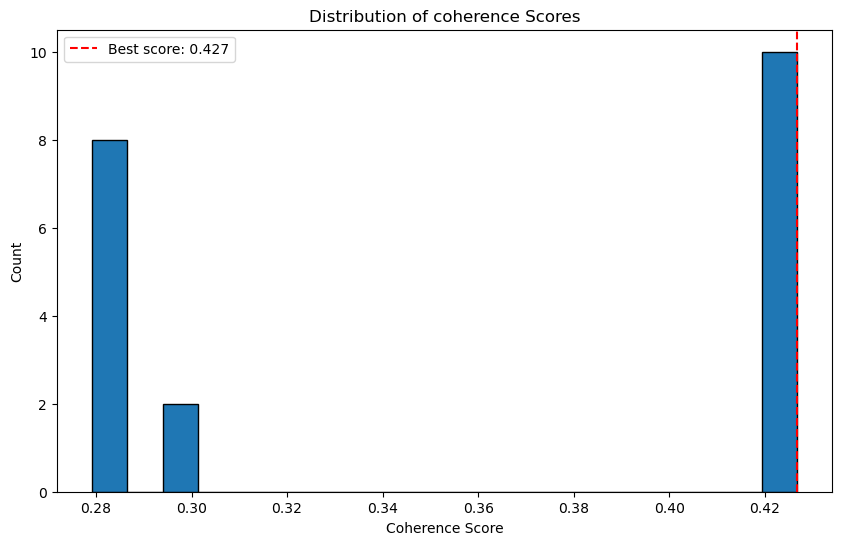

In [8]:
random_search_8 = pd.read_csv('hdbscan_optimization_results_2.csv')

results = pd.json_normalize(random_search_8['params'].apply(ast.literal_eval))
results['labels']= random_search_8['labels']
results['scores']= random_search_8['score']

# Sort by score to see best parameters
results = results.sort_values('scores', ascending=False)

# Plot the distribution of scores
plt.figure(figsize=(10, 6))
plt.hist(results['scores'], bins=20,edgecolor='black')
plt.axvline(results['scores'][0], color='r', linestyle='--', label=f'Best score: {results['scores'][0]:.3f}') # making base line 
plt.title('Distribution of coherence Scores')
plt.xlabel('Coherence Score')
plt.ylabel('Count')
plt.legend()
plt.show()


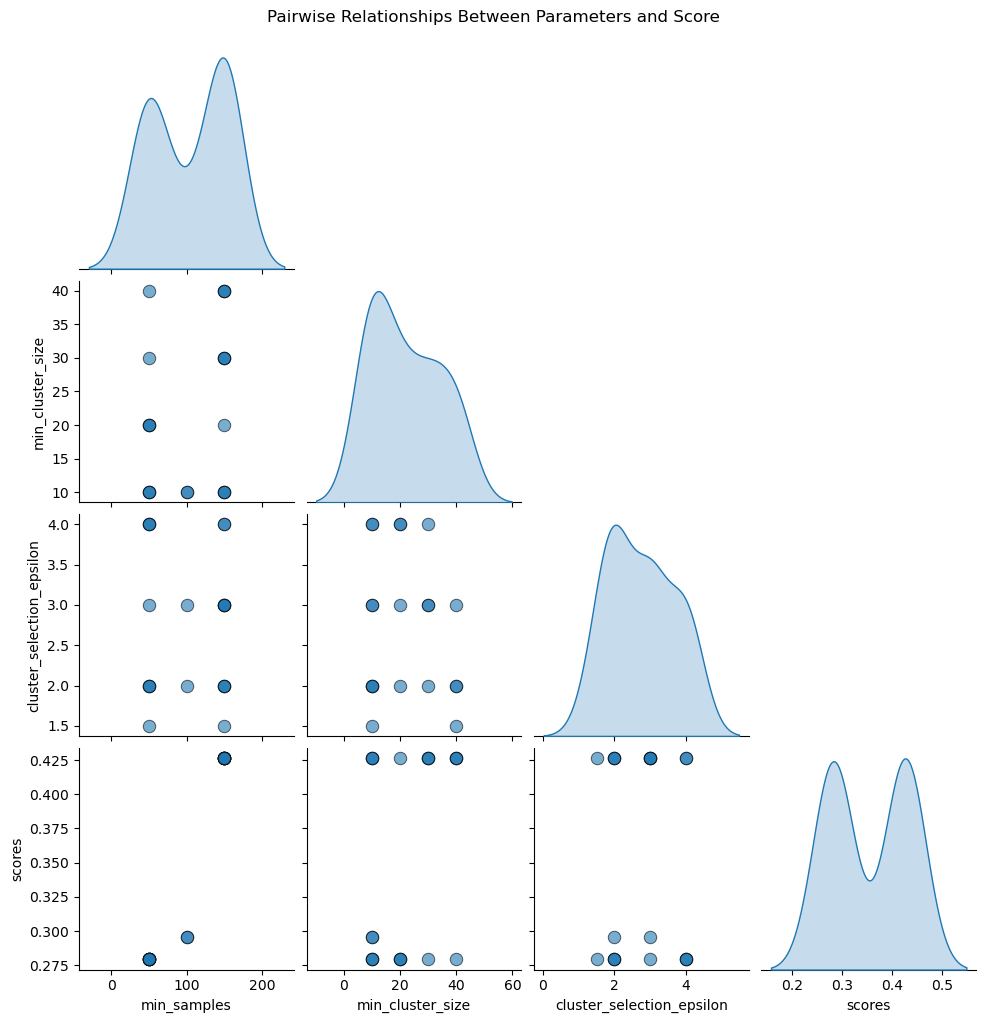

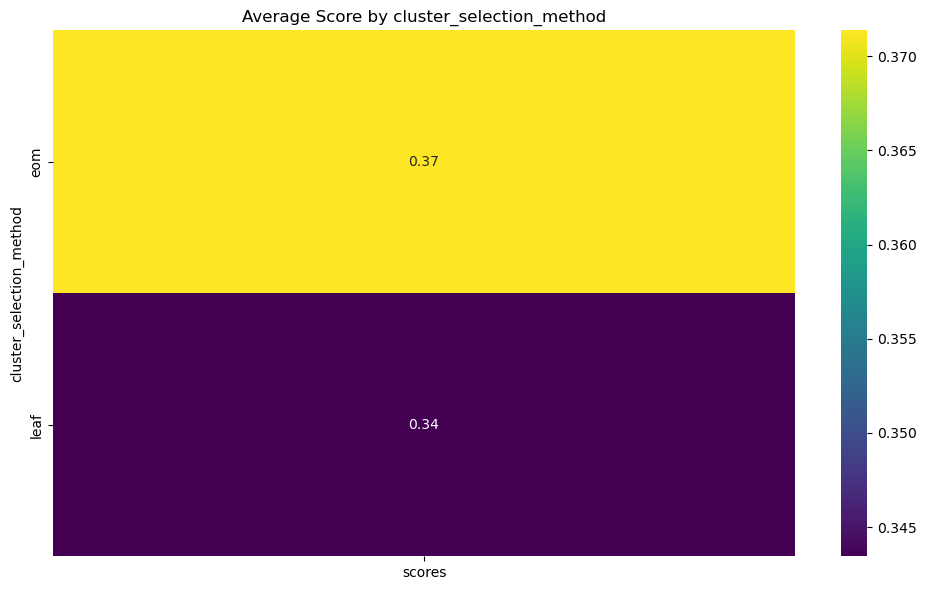

In [28]:
# Create a pairplot for numerical parameters
numerical_params = results.select_dtypes(include=['number']).columns.tolist()
# if 'scores' not in numerical_params:
    # numerical_params.append('scores')
    # Move 'scores' to the front if it's in the list
if 'scores' in numerical_params:
    numerical_params.append(numerical_params.pop(numerical_params.index('scores')))

sns.pairplot(results[numerical_params], corner=True, kind='scatter', 
             diag_kind='kde', plot_kws={'alpha': 0.6, 'edgecolor': 'k', 's': 80})
plt.suptitle('Pairwise Relationships Between Parameters and Score', y=1.02)
plt.show()

# For categorical parameters, create heatmaps
categorical_params = results.select_dtypes(include=['object']).columns.tolist()

if categorical_params:
    for param in categorical_params:
        if param == 'labels':
            continue
        plt.figure(figsize=(10, 6))
        pivot = results.pivot_table(index=param, values='scores', aggfunc=['mean', 'std', 'count'])
        sns.heatmap(pivot['mean'], annot=True, cmap='viridis')
        plt.title(f'Average Score by {param}')
        plt.tight_layout()
        plt.show()


seeing best cohernce score

In [10]:
random_search_8['params'][0]

"{'min_samples': 150, 'min_cluster_size': 40, 'cluster_selection_method': 'leaf', 'cluster_selection_epsilon': 2}"

3


/tmp/ipykernel_2041034/1073144453.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


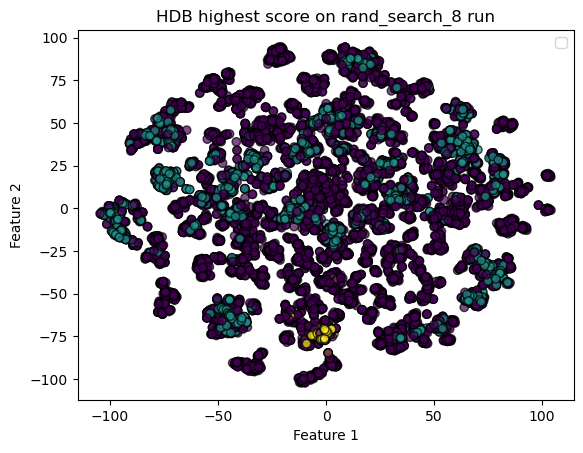

In [29]:
# Get the worst parameters
params = results.iloc[0][:-2].to_dict()

new_clusterer = hdbscan.HDBSCAN(**params)
new_clusterer.fit(vec_data)

labels = new_clusterer.labels_
print(len(np.unique(labels)))

# plot data 
data_ts= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/TSNE.npy')
plt.scatter(data_ts[:, 0], data_ts[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolors='k')

# Labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('HDB highest score on rand_search_8 run')
plt.legend()
plt.show()

# Set 3

param_dist = {
    'min_cluster_size': [20,30,40,50,60],
    'min_samples': [130,140,150,160,170],
    'cluster_selection_method':['leaf','eom'],
 
}

In [21]:


# Get the worst parameters
params = results.iloc[1,:-2].to_dict()

new_clusterer = hdbscan.HDBSCAN(**params)
new_clusterer.fit(vec_data)

labels = new_clusterer.labels_
print(len(np.unique(labels)))

3


/tmp/ipykernel_3658788/2885634220.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


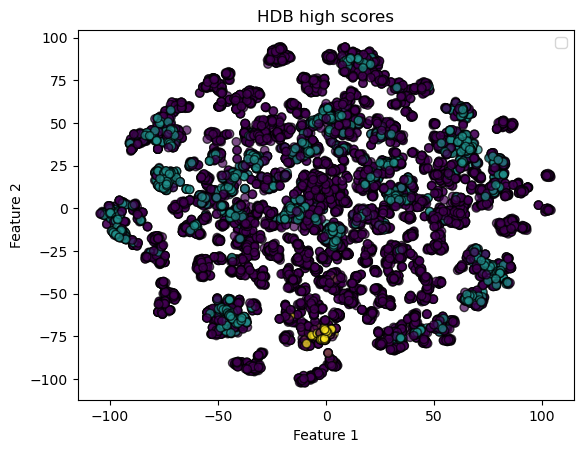

In [22]:
# plot data 
data_ts= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/TSNE.npy')
plt.scatter(data_ts[:, 0], data_ts[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolors='k')

# Labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('HDB high scores')
plt.legend()
plt.show()